# DHARMa: Simulation-Based Residuals for Mixed Models

## Overview

Standard residual diagnostics (Pearson residuals, deviance residuals, Q-Q plots) are not interpretable for GLMMs and mixed models — the expected distribution of residuals depends on the link function and error distribution, so you cannot simply look for normality.

DHARMa solves this by transforming model residuals into **scaled (randomized) residuals** that are uniformly distributed between 0 and 1 if the model is correctly specified — regardless of the model family. This makes diagnostic interpretation identical across all model types.

**How DHARMa works:**
1. Simulates n datasets from the fitted model
2. For each observation, computes where the observed value falls in the distribution of simulated values
3. This produces a value between 0 and 1 — the scaled residual
4. If the model fits, scaled residuals should follow a uniform U(0,1) distribution

## Applications by Sector

DHARMa applies to any fitted model in R — LMMs, GLMMs, GLMs, GAMs (via `mgcv`). It is the single most important diagnostic tool for non-Gaussian mixed models in ecology, healthcare modeling, and any field using count or binary outcomes with grouped data.

---

## Setup

In [7]:
library(tidyverse)
library(lme4)
library(glmmTMB)
library(DHARMa)
library(mgcv)      # GAMs — DHARMa works here too

set.seed(42)

# ── Fit reference models ──────────────────────────────────────────────────────
# LMM
data(sleepstudy, package = "lme4")
model_lmm <- lmer(Reaction ~ Days + (Days | Subject), data = sleepstudy)

# Binomial GLMM
n <- 150; g <- 15
bin_data <- tibble(
  group = rep(paste0("g", 1:g), each = n/g),
  x     = rnorm(n),
  re    = rep(rnorm(g, 0, 0.8), each = n/g),
  y     = rbinom(n, 1, plogis(-0.5 + 0.8*x + re))
)
model_bin <- lme4::glmer(y ~ x + (1|group), data = bin_data, family = binomial)

# NB GLMM
nb_data <- tibble(
  group = rep(paste0("g", 1:g), each = n/g),
  x     = rnorm(n),
  re    = rep(rnorm(g, 0, 0.5), each = n/g),
  y     = MASS::rnegbin(n, mu = exp(1.5 + 0.4*x + re), theta = 2)
)
model_nb <- glmmTMB::glmmTMB(y ~ x + (1|group), data = nb_data,
                              family = glmmTMB::nbinom2)

---

## Simulating Residuals

In [8]:
# ── Core function: simulateResiduals() ────────────────────────────────────────
sim_lmm <- DHARMa::simulateResiduals(model_lmm, n = 1000)
sim_bin <- DHARMa::simulateResiduals(model_bin, n = 1000)
sim_nb  <- DHARMa::simulateResiduals(model_nb,  n = 1000)

# n: number of simulations — 250 is minimum; 1000 is recommended for publications
# More simulations = smoother QQ curve and more stable test statistics
# For large datasets (n > 10000): use n = 500 for computational efficiency

# ── Inspect the simulated residuals object ────────────────────────────────────
str(sim_lmm)
# scaledResiduals: the U(0,1) residuals — these are what get plotted and tested
# fittedValues: model predicted values
# observedResponse: original response values

List of 17
 $ fittedModel            :Formal class 'lmerMod' [package "lme4"] with 13 slots
  .. ..@ resp   :Reference class 'lmerResp' [package "lme4"] with 9 fields
  .. .. ..$ Ptr    :<externalptr> 
  .. .. ..$ mu     : num [1:180] 254 273 293 313 332 ...
  .. .. ..$ offset : num [1:180] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..$ sqrtXwt: num [1:180] 1 1 1 1 1 1 1 1 1 1 ...
  .. .. ..$ sqrtrwt: num [1:180] 1 1 1 1 1 1 1 1 1 1 ...
  .. .. ..$ weights: num [1:180] 1 1 1 1 1 1 1 1 1 1 ...
  .. .. ..$ wtres  : num [1:180] -4.1 -14.63 -42.2 8.78 24.52 ...
  .. .. ..$ y      : num [1:180] 250 259 251 321 357 ...
  .. .. ..$ REML   : int 2
  .. .. ..and 28 methods, of which 14 are  possibly relevant:
  .. .. ..  allInfo, copy#envRefClass, initialize, initialize#lmResp,
  .. .. ..  initializePtr, initializePtr#lmResp, objective, ptr, ptr#lmResp,
  .. .. ..  setOffset, setResp, setWeights, updateMu, wrss
  .. ..@ Gp     : int [1:2] 0 36
  .. ..@ call   : language lmer(formula = Reaction ~ Days + (D

---

## The Main Diagnostic Plot

The standard `plot()` call produces two panels that together cover the most important diagnostics.

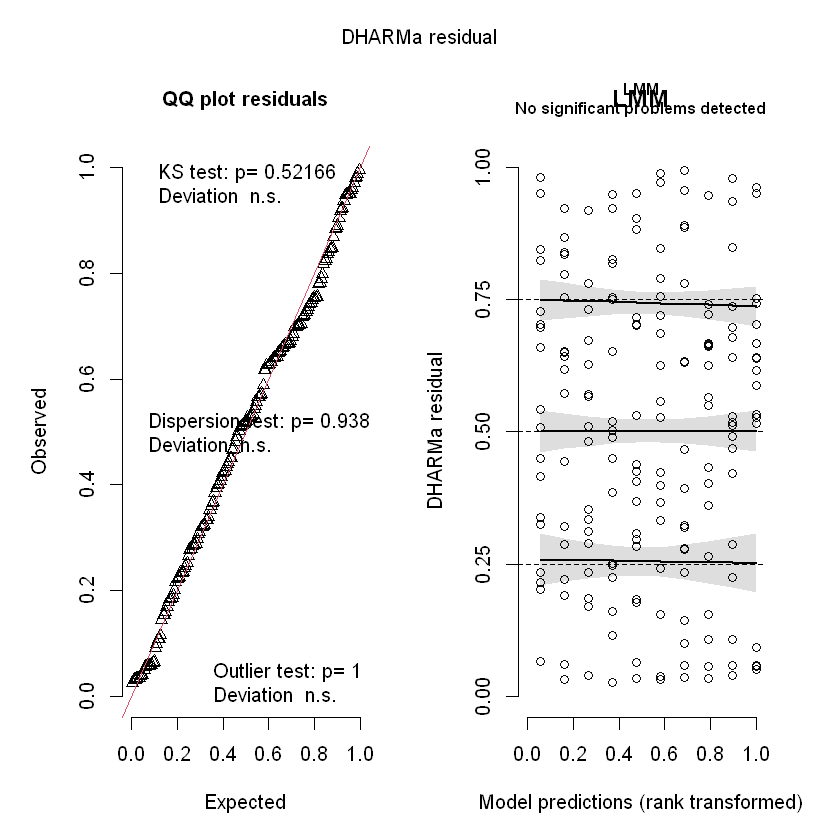

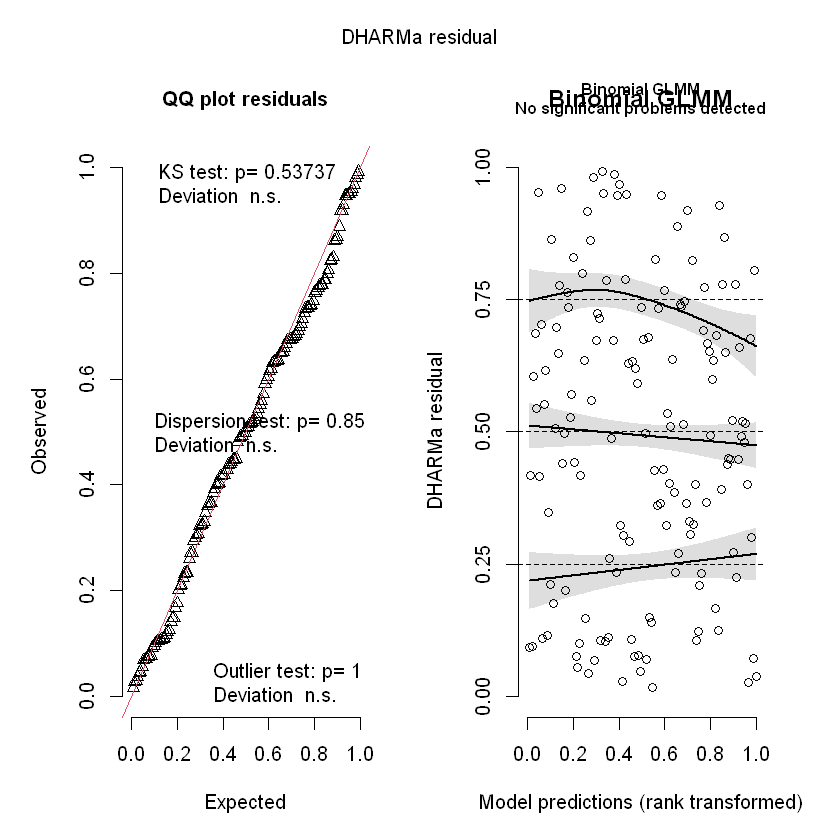

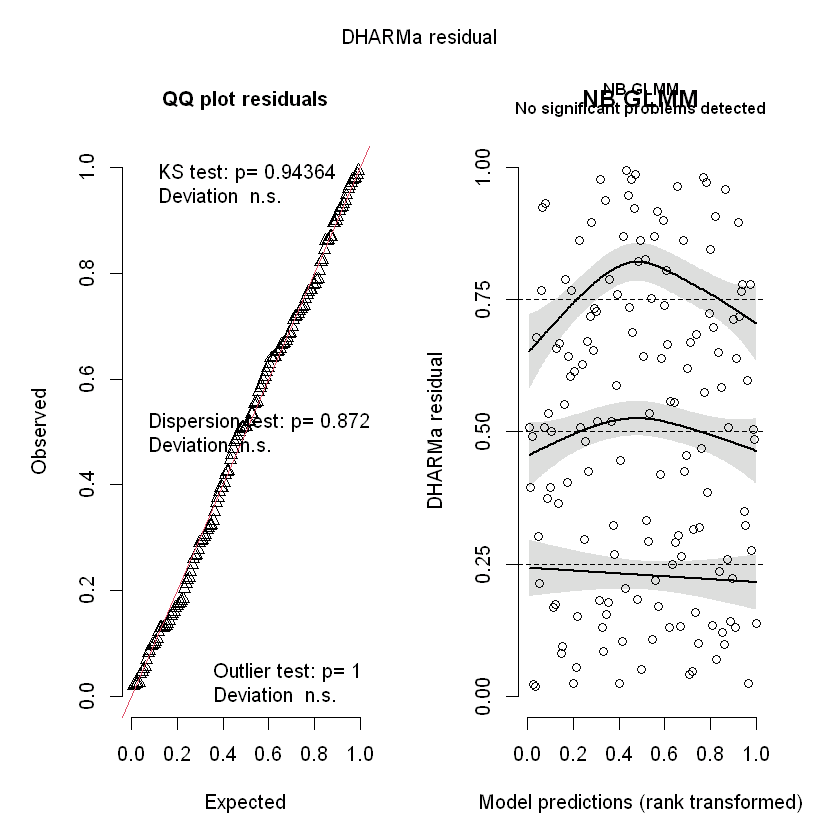

In [9]:
# ── Standard DHARMa plot: two panels ─────────────────────────────────────────
par(mfrow = c(1, 3))
plot(sim_lmm, main = "LMM")
plot(sim_bin, main = "Binomial GLMM")
plot(sim_nb,  main = "NB GLMM")
par(mfrow = c(1, 1))

# ── Reading the two-panel plot ────────────────────────────────────────────────
# LEFT PANEL — QQ plot of scaled residuals:
#   Points on the diagonal → residuals are uniform → model fits well
#   Deviation from diagonal → systematic misfit
#   Significant KS test (p < 0.05) → formal evidence of non-uniformity
#   Dispersion test shown on plot: significant = over/underdispersion
#   Outlier test shown on plot: significant = outliers

# RIGHT PANEL — Residuals vs. predicted (rank-transformed):
#   Points distributed uniformly across y-axis → no systematic pattern
#   S-shaped pattern → non-linearity
#   Fan shape → heteroscedasticity
#   Clustering → data structure not accounted for

---

## Specific Diagnostic Tests


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.88701, p-value = 0.872
alternative hypothesis: two.sided


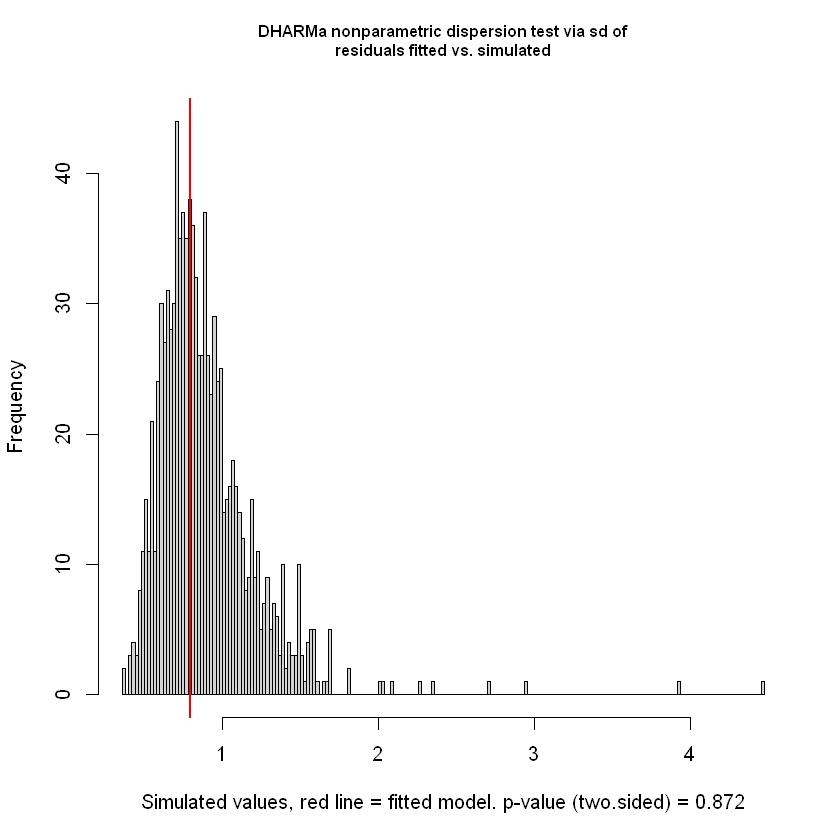


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.96374, p-value = 1
alternative hypothesis: two.sided


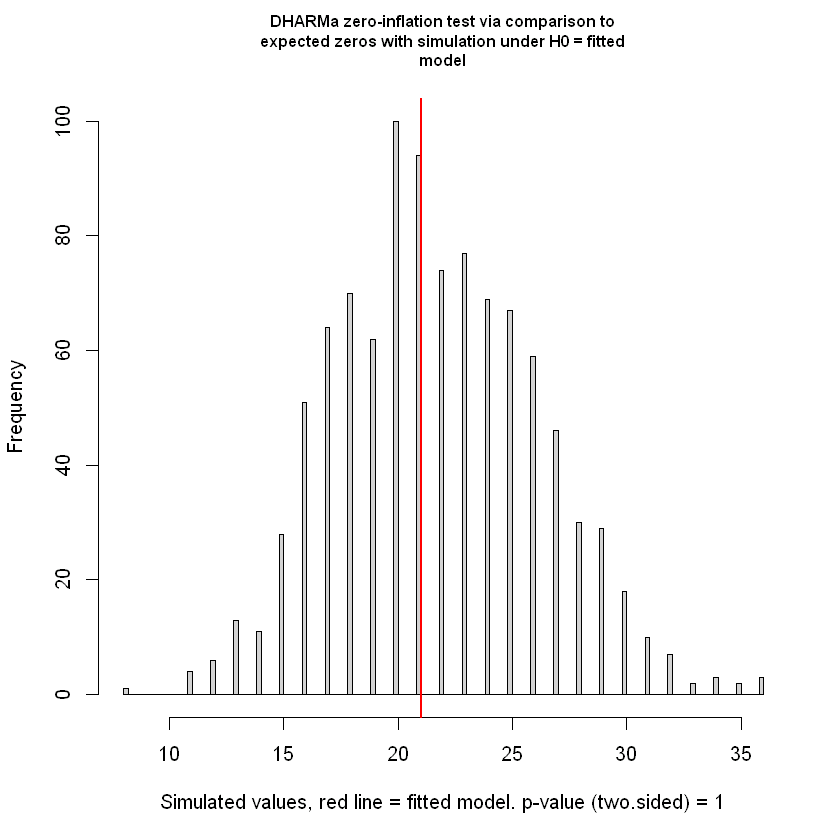


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  simulationOutput$scaledResiduals
D = 0.043065, p-value = 0.9436
alternative hypothesis: two-sided


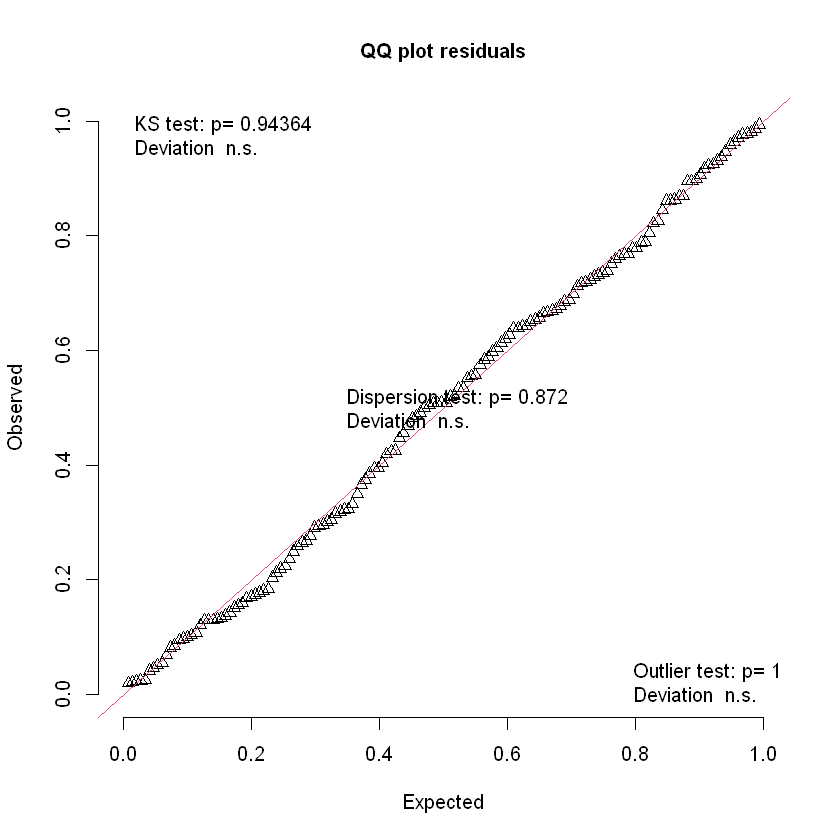


	DHARMa bootstrapped outlier test

data:  sim_nb
outliers at both margin(s) = 0, observations = 150, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0.00000000 0.01016667
sample estimates:
outlier frequency (expected: 0.0014 ) 
                                    0 


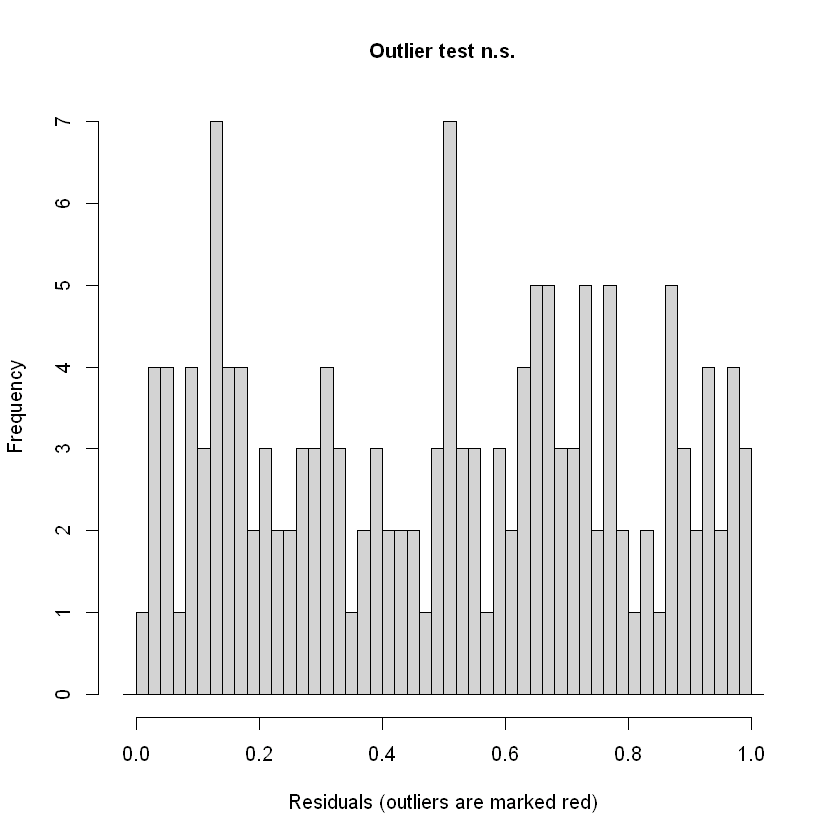

In [10]:
# ── 1. Overdispersion test ────────────────────────────────────────────────────
# Tests whether variance > expected for the model family
# Critical for Poisson and binomial models
DHARMa::testDispersion(sim_nb)
# p < 0.05: significant over/underdispersion
# Red line to the left of distribution: overdispersed
# Red line to the right: underdispersed

# ── 2. Zero-inflation test ────────────────────────────────────────────────────
# Tests whether observed proportion of zeros exceeds model prediction
# Important for Poisson and NB models
DHARMa::testZeroInflation(sim_nb)
# p < 0.05: more zeros than model predicts → consider zero-inflated model

# ── 3. Uniformity test (KS test) ─────────────────────────────────────────────
# Tests whether scaled residuals follow U(0,1) — the null expectation
DHARMa::testUniformity(sim_nb)

# ── 4. Outlier test ───────────────────────────────────────────────────────────
# Observations at the extreme tails of their simulated distribution
# (scaled residual = 0 or 1 exactly)
DHARMa::testOutliers(sim_nb)
# p < 0.05: more extreme observations than expected by chance

---

## Residuals vs. Predictors

Plotting residuals against each predictor and grouping variable helps identify non-linearity, heteroscedasticity within groups, and unmodeled structure.

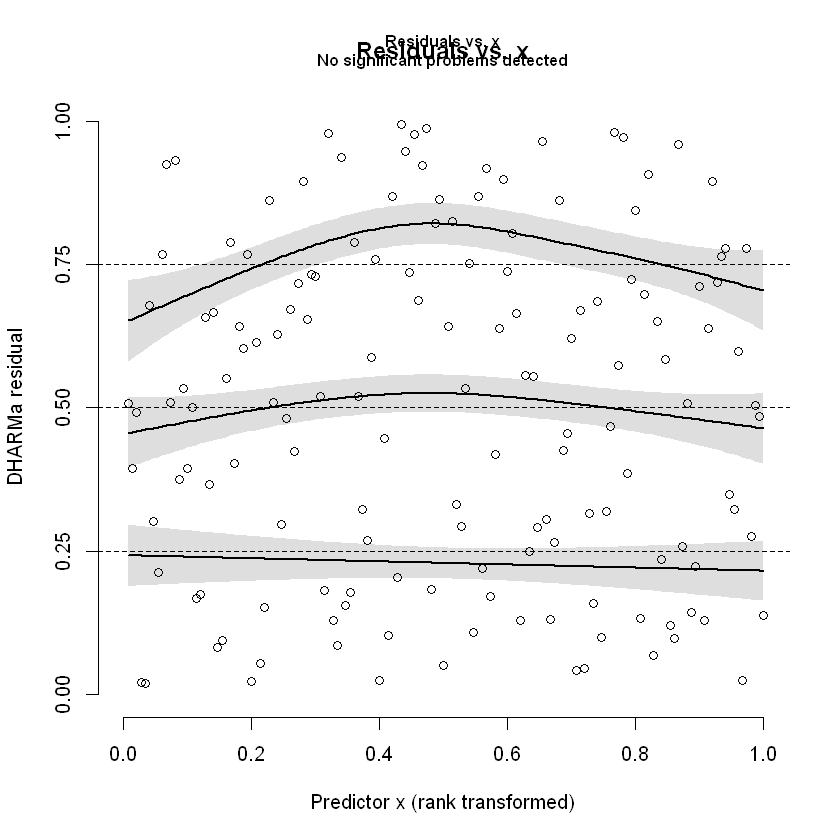

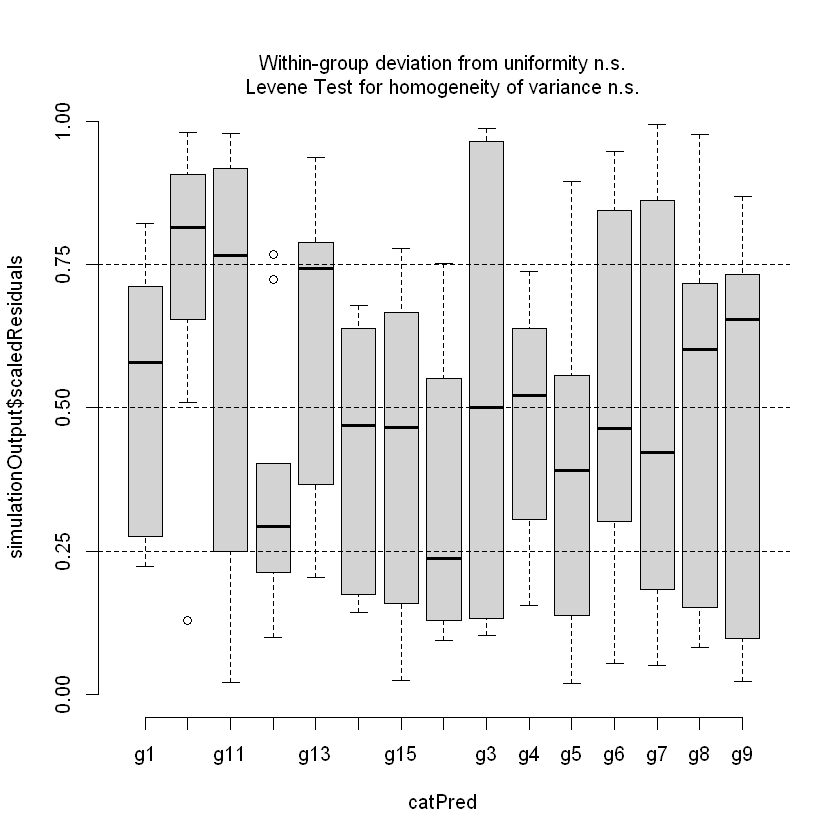


	Durbin-Watson test

data:  simulationOutput$scaledResiduals ~ 1
DW = 2.0108, p-value = 0.9858
alternative hypothesis: true autocorrelation is not 0


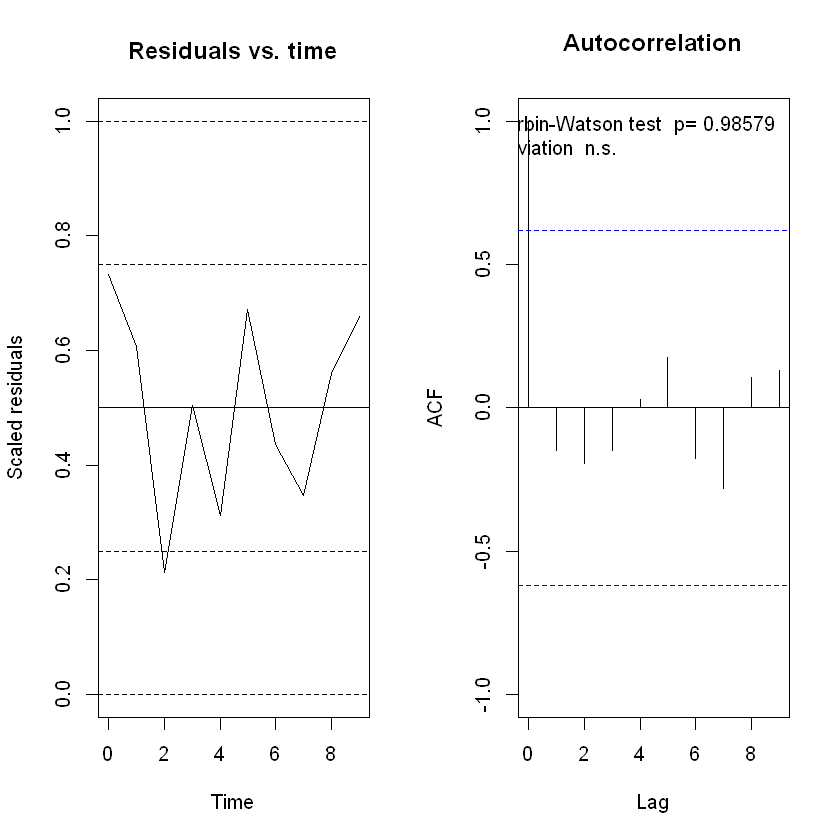

In [11]:
# ── Residuals vs. continuous predictor ───────────────────────────────────────
DHARMa::plotResiduals(
  sim_nb,
  form = nb_data$x,
  xlab = "Predictor x",
  main = "Residuals vs. x"
)
# Flat quantile lines (0.25, 0.5, 0.75) = good fit
# Curved quantile lines = non-linearity in predictor relationship
# Fan shape = heteroscedasticity

# ── Residuals vs. grouping variable ──────────────────────────────────────────
DHARMa::plotResiduals(
  sim_nb,
  form = as.factor(nb_data$group),
  xlab = "Group",
  main = "Residuals by Group"
)
# Each box should be approximately uniform
# A group with skewed residuals may need a different random effects structure

# ── Temporal autocorrelation test ─────────────────────────────────────────────
# For longitudinal data: check if residuals are correlated within groups over time
aggregated_residuals <- DHARMa::recalculateResiduals(
  simulationOutput = sim_lmm,
  group = sleepstudy$Days
)
DHARMa::testTemporalAutocorrelation(
  simulationOutput = aggregated_residuals,
  time = unique(sleepstudy$Days)
)
# p < 0.05: significant temporal autocorrelation not accounted for by the model
# Solution: add AR1 correlation structure (available in nlme::lme or glmmTMB)

# ── Spatial autocorrelation test ──────────────────────────────────────────────
# For spatially structured data: check if residuals cluster in space
# DHARMa::testSpatialAutocorrelation(
#   simulationOutput = sim_nb,
#   x = coordinates_x,
#   y = coordinates_y
# )

---

## Recognizing Common Misspecification Patterns

The examples below deliberately fit wrong models to show what each failure mode looks like in DHARMa.

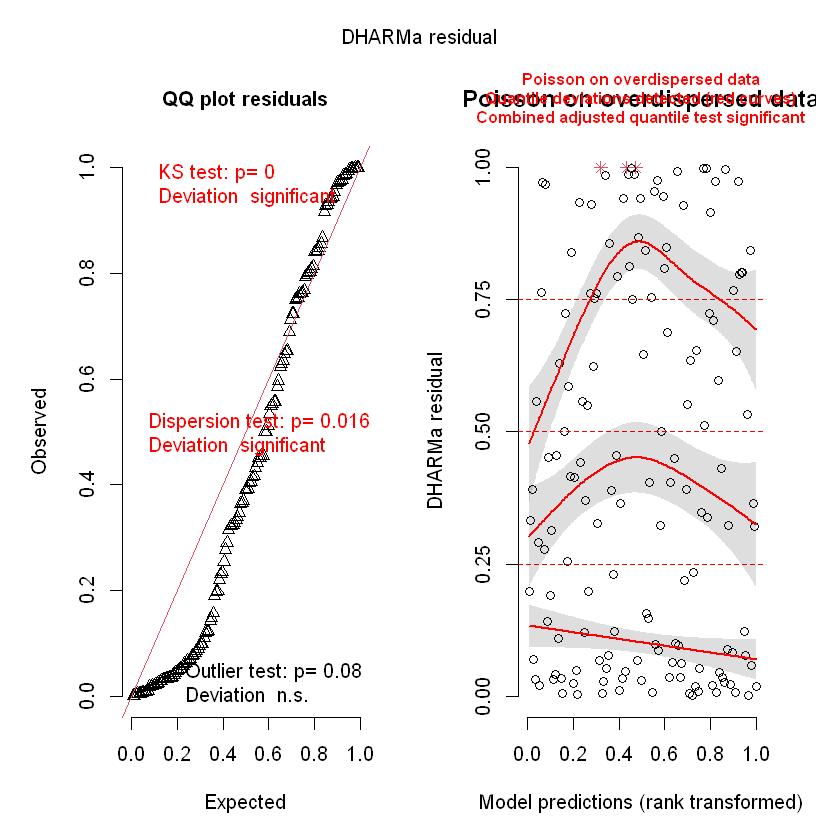

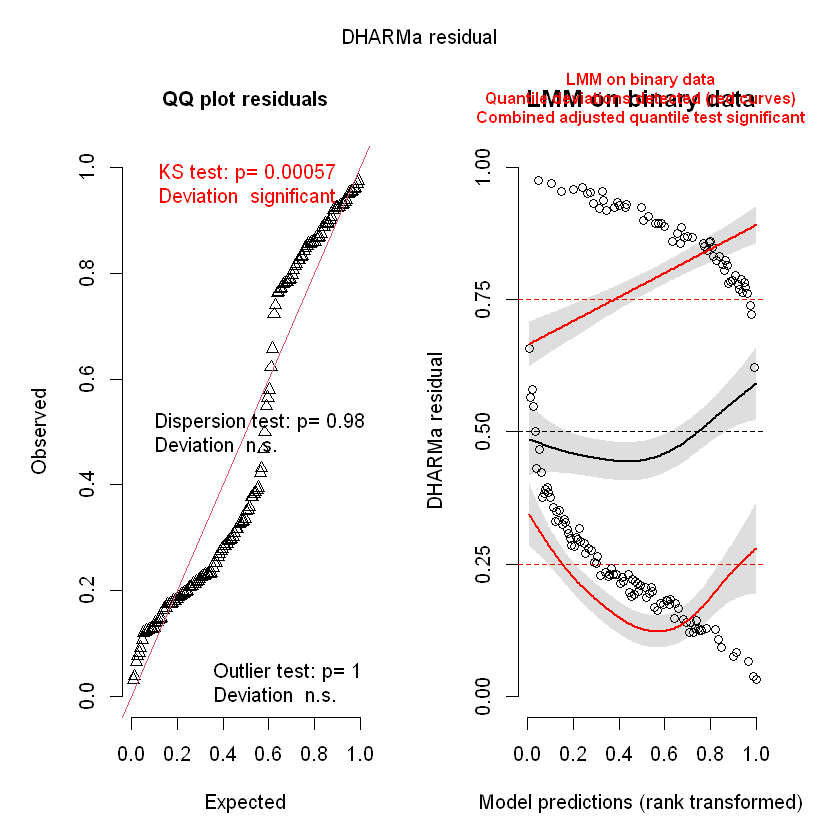

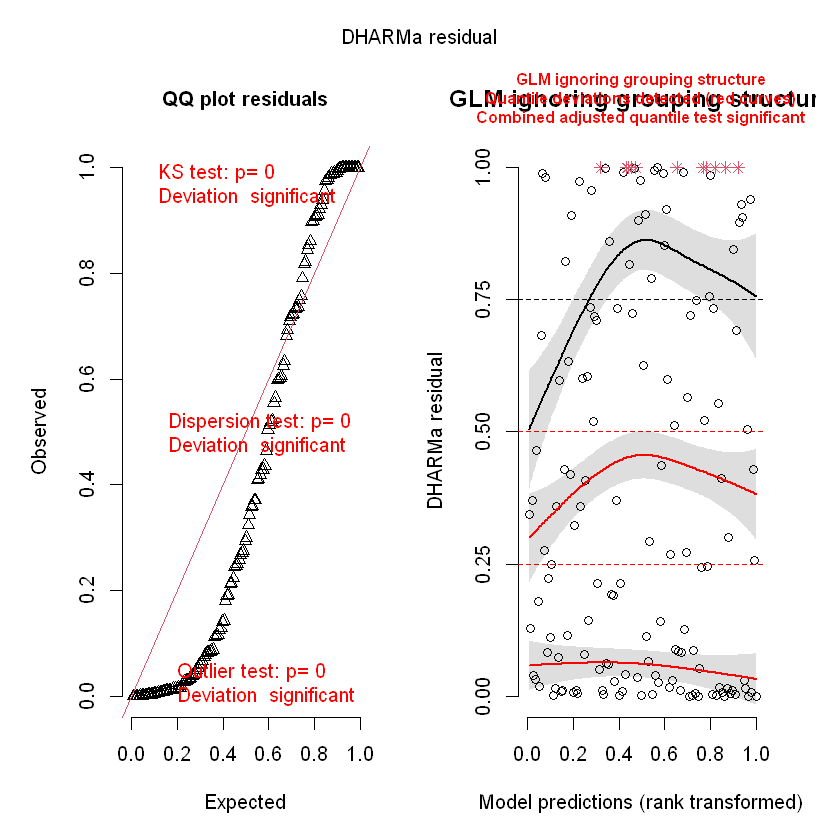

In [12]:
# ── Example 1: Poisson on overdispersed data ──────────────────────────────────
wrong_pois <- lme4::glmer(y ~ x + (1|group), data = nb_data, family = poisson)
sim_wrong  <- DHARMa::simulateResiduals(wrong_pois, n = 1000)
par(mfrow = c(1, 2))
plot(sim_wrong, main = "Poisson on overdispersed data")
# QQ: points arc above diagonal → too many large residuals (overdispersion)
# Dispersion test: significant with ratio > 1

# ── Example 2: LMM on binary data ────────────────────────────────────────────
wrong_lmm  <- lmer(y ~ x + (1|group), data = bin_data)
sim_wrong2 <- DHARMa::simulateResiduals(wrong_lmm, n = 1000)
plot(sim_wrong2, main = "LMM on binary data")
# Severe deviation from uniformity — wrong family entirely
par(mfrow = c(1, 1))

# ── Example 3: Missing random effect ─────────────────────────────────────────
wrong_glm  <- glm(y ~ x, data = nb_data, family = poisson)
sim_wrong3 <- DHARMa::simulateResiduals(wrong_glm, n = 1000)
plot(sim_wrong3, main = "GLM ignoring grouping structure")
# Residuals vs. predicted: clustering pattern; overdispersion from ignored variance

---

## Quick Interpretation Guide

| What You See | Likely Cause | Possible Fix |
|---|---|---|
| QQ arcs above diagonal | Overdispersion | Switch to NB or add overdispersion parameter |
| QQ arcs below diagonal | Underdispersion | Rare; check for truncation or ceiling effects |
| Too many 0s or 1s in residuals | Zero-inflation or outliers | Zero-inflated model; investigate outliers |
| Curved pattern in residuals vs. fitted | Non-linearity | Add polynomial term or use GAM |
| Fan shape in residuals vs. fitted | Heteroscedasticity | Transform response or use variance structure |
| Significant temporal autocorrelation | Unmodeled time structure | Add AR1 correlation (nlme or glmmTMB) |
| Significant spatial autocorrelation | Unmodeled spatial structure | Add spatial correlation or spatial random effect |
| Residual pattern by group | Random effects misspecified | Add random slope; check group-level outliers |

---

## Common Pitfalls

**1. Using base R `plot(model)` instead of DHARMa for GLMMs**  
Standard diagnostic plots are only appropriate for linear models with Gaussian errors. For anything else — binomial, Poisson, NB, Gamma — use DHARMa.

**2. Using too few simulations**  
With `n = 100` or fewer, the KS and other tests have low power and the QQ curve is noisy. Use `n = 1000` for publications; `n = 250` is acceptable for exploratory work.

**3. Over-interpreting marginal significance in large datasets**  
With large n, even minor deviations from model assumptions become statistically significant. Use the test statistics as guides but focus on the magnitude of deviations in the plots.

**4. Not testing specific predictors**  
The global QQ plot can look fine while a specific predictor has a strongly non-linear relationship. Always plot residuals against each predictor separately with `plotResiduals()`.

**5. Ignoring temporal and spatial autocorrelation tests**  
These are especially important in ecology and longitudinal health data. Unmodeled autocorrelation inflates type I error in the same way that ignoring random effects does.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*